# Veri Hazırlık — Temizlik + Grup-Aware Split

`rt_seg_veri_analizi.ipynb` çıktılarını girdi alır, eğitimin tüketeceği **manifest** dosyasını üretir.

EDA sonrası verilen kararlar:

1. **Çelişkili etiketli çiftlerde tek temsilci** — korelasyon > 0.95 ama maske IoU < 0.5 olan çiftlerde biri elenir
2. **Grup-aware split** — kopya grupları asla train/val/test arasında bölünmez
3. **70 / 15 / 15** train / val / test, sınıf + lezyon boyutu ile stratify
4. `normal` sınıfı (boş maske) negatif örnek olarak dahil

Çıktı: `veri_manifest.csv` (eğitimin okuyacağı tek dosya) + `splits.json` + doğrulama raporu.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, re, json, shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = '/content/drive/MyDrive/real_time_segmentasyon/Dataset_BUSI_with_GT'
EDA_DIR = '/content/drive/MyDrive/real_time_segmentasyon/eda'
DRIVE_DIR = '/content/drive/MyDrive/real_time_segmentasyon/veri'
LOCAL_DIR = '/content/outputs/veri'

for d in [DRIVE_DIR, LOCAL_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

CLASSES = ['benign', 'malignant', 'normal']
CLASS_COLORS = {'benign': 'tab:green', 'malignant': 'tab:red', 'normal': 'tab:blue'}
SPLIT_NAMES = ['train', 'val', 'test']
SPLIT_COLORS = {'train': 'tab:blue', 'val': 'tab:orange', 'test': 'tab:green'}

SEED = 42
RATIOS = (0.70, 0.15, 0.15)
IOU_CONFLICT = 0.5      # EDA ile ayni esik
N_SIZE_BINS = 3         # lezyon boyutu stratify bini


def mirror_to_local(drive_path):
    dst = Path(LOCAL_DIR) / Path(drive_path).name
    shutil.copy2(drive_path, dst)
    return str(dst)


print('EDA cikti klasoru:', EDA_DIR)
print('Mevcut dosyalar  :', sorted(os.listdir(EDA_DIR)) if os.path.isdir(EDA_DIR) else 'YOK - once EDA notebook calistirilmali')

Mounted at /content/drive
EDA cikti klasoru: /content/drive/MyDrive/real_time_segmentasyon/eda
Mevcut dosyalar  : ['eda_cozunurluk_analizi.xlsx', 'eda_kopya_ciftler.xlsx', 'eda_kopya_gruplari.xlsx', 'eda_ozet_raporu.md', 'eda_vaka_istatistikleri.xlsx', 'figurler']


## 1. EDA çıktılarını yükle

In [2]:
stats = pd.read_excel(f'{EDA_DIR}/eda_vaka_istatistikleri.xlsx')
groups = pd.read_excel(f'{EDA_DIR}/eda_kopya_gruplari.xlsx')[['case_id', 'group_id']]
pairs = pd.read_excel(f'{EDA_DIR}/eda_kopya_ciftler.xlsx')

df = stats.merge(groups, on='case_id', how='left')
assert df['group_id'].notna().all(), 'group_id eslesmeyen vaka var'
df['group_id'] = df['group_id'].astype(int)

# goruntu ve maske yollarini yeniden kur (manifest icin gerekli)
MASK_RE = re.compile(r'^(?P<stem>.+?)_mask(?:_(?P<idx>\d+))?\.png$', re.IGNORECASE)
mask_index = defaultdict(list)
for cls in CLASSES:
    for p in sorted((Path(DATA_ROOT) / cls).glob('*.png')):
        m = MASK_RE.match(p.name)
        if m:
            mask_index[f'{cls}/{m.group("stem")}'].append(p.name)

df['image_path'] = [f'{DATA_ROOT}/{c.split("/")[0]}/{c.split("/")[1]}.png' for c in df['case_id']]
df['mask_paths'] = [';'.join(f'{DATA_ROOT}/{c.split("/")[0]}/{n}'
                             for n in sorted(mask_index[c], key=lambda s: (len(s), s)))
                    for c in df['case_id']]
assert (df['mask_paths'].str.len() > 0).all(), 'maske yolu bos olan vaka var'

print('Yuklenen vaka:', len(df))
print('Kopya cifti  :', len(pairs), '| teyitli kopya:', int(pairs['kopya'].sum()))
print('Grup sayisi  :', df['group_id'].nunique())
df[['case_id', 'cls', 'group_id', 'lesion_px', 'lesion_ratio']].head()

Yuklenen vaka: 780
Kopya cifti  : 196 | teyitli kopya: 115
Grup sayisi  : 681


,case_id,cls,group_id,lesion_px,lesion_ratio
0,benign/benign (1),benign,185,984,0.003717
1,benign/benign (10),benign,191,32918,0.082387
2,benign/benign (100),benign,0,10011,0.065526
3,benign/benign (101),benign,1,4167,0.015648
4,benign/benign (102),benign,2,18857,0.048759


## 2. Çelişkili etiketli çiftlerin temizliği

Korelasyonu > 0.95 ama maske IoU'su < 0.5 olan çiftler: aynı görüntü, uyuşmayan anotasyon. Otomatik hakemlik mümkün değil, o yüzden **deterministik ve kayıt altına alınan** bir kuralla tek temsilci bırakılır:

1. Çiftin bir üyesinin maskesi boşsa o elenir — kopyasında lezyon işaretliyken boş maske kesin hatalı.
2. İkisi de doluysa **küçük anotasyonlu** olan elenir (eksik işaretleme, fazla işaretlemeden daha olası).

`MANUAL_DROP` / `MANUAL_KEEP` listeleriyle kural elle geçersiz kılınabilir — aşağıdaki görselden inceleyip müdahale edilebilir.

In [3]:
MANUAL_DROP = []   # ornek: ['benign/benign (299)'] - kuraldan bagimsiz elenecekler
MANUAL_KEEP = []   # kural elemis olsa bile tutulacaklar

lut = stats.set_index('case_id')
conf = pairs[pairs['etiket_celiskisi']].sort_values('corr', ascending=False)

drop, kayit = set(), []
for _, p in conf.iterrows():
    if p['a'] in drop or p['b'] in drop:
        continue   # cift zaten cozulmus (ucgen iliskiler)
    la, lb = lut.loc[p['a'], 'lesion_px'], lut.loc[p['b'], 'lesion_px']
    if la == 0:
        d, k, why = p['a'], p['b'], 'bos maske, kopyasinda lezyon var'
    elif lb == 0:
        d, k, why = p['b'], p['a'], 'bos maske, kopyasinda lezyon var'
    elif la < lb:
        d, k, why = p['a'], p['b'], 'kucuk anotasyon (eksik isaretleme olasi)'
    else:
        d, k, why = p['b'], p['a'], 'kucuk anotasyon (eksik isaretleme olasi)'
    drop.add(d)
    kayit.append(dict(atilan=d, tutulan=k, corr=round(p['corr'], 3),
                      mask_iou=round(p['mask_iou'], 3), gerekce=why))

drop = (drop | set(MANUAL_DROP)) - set(MANUAL_KEEP)
temizlik = pd.DataFrame(kayit)

print('Celiskili cift:', len(conf), '| elenen goruntu:', len(drop))
print(temizlik.to_string(index=False))

df['elendi'] = df['case_id'].isin(drop)
clean = df[~df['elendi']].reset_index(drop=True)
print(f'\n{len(df)} -> {len(clean)} goruntu')
print(clean['cls'].value_counts().reindex(CLASSES).to_string())

TEMIZLIK_XLSX = f'{DRIVE_DIR}/temizlik_kayit.xlsx'
temizlik.to_excel(TEMIZLIK_XLSX, index=False)
mirror_to_local(TEMIZLIK_XLSX)

Celiskili cift: 11 | elenen goruntu: 11
                   atilan                  tutulan  corr  mask_iou                                  gerekce
      benign/benign (299)      benign/benign (233) 0.999     0.149 kucuk anotasyon (eksik isaretleme olasi)
malignant/malignant (116) malignant/malignant (18) 0.998     0.116 kucuk anotasyon (eksik isaretleme olasi)
      benign/benign (306)      benign/benign (228) 0.992     0.442 kucuk anotasyon (eksik isaretleme olasi)
 malignant/malignant (51)      benign/benign (131) 0.989     0.292 kucuk anotasyon (eksik isaretleme olasi)
      benign/benign (254)      benign/benign (211) 0.984     0.282 kucuk anotasyon (eksik isaretleme olasi)
      benign/benign (321)        benign/benign (4) 0.979     0.200 kucuk anotasyon (eksik isaretleme olasi)
       normal/normal (34)      benign/benign (437) 0.978     0.000         bos maske, kopyasinda lezyon var
        normal/normal (1)      benign/benign (269) 0.977     0.000         bos maske, kopyasinda

'/content/outputs/veri/temizlik_kayit.xlsx'

## 3. Grup-aware stratified split

**Birim: grup, görüntü değil.** Her kopya grubu bütün olarak tek bir bölüme atanır.

Stratum = sınıf × lezyon boyutu bini (lezyonlu gruplarda 3 çeyreklik bin; `normal` kendi stratumu). Her stratum içinde gruplar karıştırılır, büyükten küçüğe hedefe göre en çok geride kalan bölüme verilir — büyük grupların yarattığı dengesizlik erken telafi edilir.

In [4]:
def grup_bilgisi(frame, n_bins=N_SIZE_BINS):
    g = frame.groupby('group_id')
    gi = pd.DataFrame({'size': g.size(),
                       'cls': g['cls'].agg(lambda s: s.mode()[0]),
                       'ratio': g['lesion_ratio'].mean()})
    lm = gi['ratio'] > 0
    gi['bin'] = 'none'
    gi.loc[lm, 'bin'] = pd.qcut(gi.loc[lm, 'ratio'], n_bins,
                                labels=['s', 'm', 'l'][:n_bins]).astype(str)
    gi['stratum'] = gi['cls'] + '_' + gi['bin']
    return gi


def stratified_group_split(gi, ratios=RATIOS, seed=SEED):
    rng = np.random.RandomState(seed)
    assign = {}
    for _, sub in gi.groupby('stratum'):
        idx = sub.index.to_numpy().copy()
        rng.shuffle(idx)
        # buyuk gruplar once: dengesizlik erken duzeltilsin
        order = idx[np.argsort(-sub.loc[idx, 'size'].to_numpy(), kind='stable')]
        counts = np.zeros(len(ratios))
        total = sub['size'].sum()
        for gid in order:
            k = int(np.argmax(np.array(ratios) * total - counts))
            assign[gid] = k
            counts[k] += gi.loc[gid, 'size']
    return assign


ginfo = grup_bilgisi(clean)
print('Stratum dagilimi:')
print(ginfo.groupby('stratum').agg(grup=('size', 'size'), goruntu=('size', 'sum')).to_string())

assign = stratified_group_split(ginfo)
clean['split'] = [SPLIT_NAMES[assign[g]] for g in clean['group_id']]

tab = pd.crosstab(clean['split'], clean['cls']).reindex(SPLIT_NAMES)
tab['TOPLAM'] = tab.sum(axis=1)
tab['%'] = (100 * tab['TOPLAM'] / len(clean)).round(1)
print('\n=== Split ===')
print(tab.to_string())

print('\nSinif oranlari (%):')
print((100 * pd.crosstab(clean['split'], clean['cls'], normalize='index')).round(1).reindex(SPLIT_NAMES).to_string())

lc = clean[clean['lesion_px'] > 0]
lr = lc.groupby('split')['lesion_ratio'].agg(['count', 'mean', 'median'])
lr[['mean', 'median']] = (lr[['mean', 'median']] * 100).round(2)
print('\nLezyon alan orani (%) split bazinda:')
print(lr.reindex(SPLIT_NAMES).to_string())

Stratum dagilimi:
             grup  goruntu
stratum                   
benign_l       77       92
benign_m      118      138
benign_s      177      202
malignant_l   113      115
malignant_m    72       78
malignant_s    13       13
normal_none   111      131

=== Split ===
cls    benign  malignant  normal  TOPLAM     %
split                                         
train     300        146      92     538  70.0
val        65         31      20     116  15.1
test       65         31      19     115  15.0

Sinif oranlari (%):
cls    benign  malignant  normal
split                           
train    55.8       27.1    17.1
val      56.0       26.7    17.2
test     56.5       27.0    16.5

Lezyon alan orani (%) split bazinda:
       count   mean  median
split                      
train    446   9.33    5.62
val       96  10.19    5.97
test      96   9.71    6.25


## 4. Doğrulama

Split'in taşıması gereken iki kesin garanti: hiçbir grup bölünmemiş olacak, hiçbir teyitli kopya çifti iki farklı bölüme düşmeyecek. Bu hücre ikisini de sert şekilde (assert) kontrol eder.

Birden fazla bolume dagilan grup: 0
Bolumler arasi bolunmus kopya cifti: 0

Tum kontroller gecti.


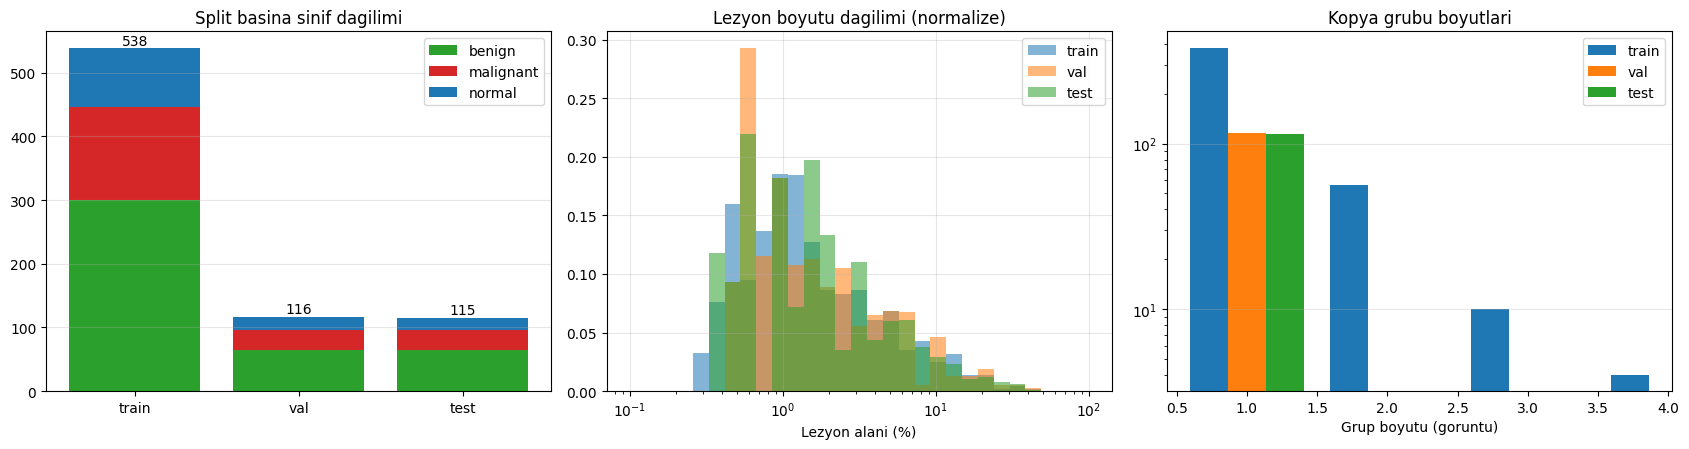

In [5]:
gs = clean.groupby('group_id')['split'].nunique()
bolunmus = int((gs > 1).sum())

sp = clean.set_index('case_id')['split'].to_dict()
sizinti = []
for _, p in pairs[pairs['kopya']].iterrows():
    a, b = sp.get(p['a']), sp.get(p['b'])
    if a and b and a != b:
        sizinti.append((p['a'], a, p['b'], b, round(p['corr'], 3)))

print('Birden fazla bolume dagilan grup:', bolunmus)
print('Bolumler arasi bolunmus kopya cifti:', len(sizinti))
for s in sizinti:
    print('   SIZINTI:', s)

assert bolunmus == 0, 'Grup butunlugu bozuldu'
assert len(sizinti) == 0, 'Kopya cifti bolumler arasina dagildi'
assert len(clean) == len(set(clean['case_id'])), 'Tekrarli case_id'
print('\nTum kontroller gecti.')

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))

bottom = np.zeros(3)
for c in CLASSES:
    v = tab[c].to_numpy()
    ax[0].bar(SPLIT_NAMES, v, bottom=bottom, label=c, color=CLASS_COLORS[c])
    bottom += v
for i, t in enumerate(tab['TOPLAM']):
    ax[0].text(i, t + 6, str(int(t)), ha='center')
ax[0].set_title('Split basina sinif dagilimi'); ax[0].legend(); ax[0].grid(alpha=0.3, axis='y')

for s in SPLIT_NAMES:
    v = lc[lc['split'] == s]['lesion_ratio'] * 100
    ax[1].hist(v, bins=np.logspace(-1, 2, 30), alpha=0.55, label=s, color=SPLIT_COLORS[s], density=True)
ax[1].set_xscale('log'); ax[1].set_xlabel('Lezyon alani (%)')
ax[1].set_title('Lezyon boyutu dagilimi (normalize)'); ax[1].legend(); ax[1].grid(alpha=0.3)

gsz = clean.groupby(['split', 'group_id']).size().reset_index(name='n')
for i, s in enumerate(SPLIT_NAMES):
    v = gsz[gsz['split'] == s]['n'].value_counts().sort_index()
    ax[2].bar(v.index + (i - 1) * 0.27, v.values, width=0.27, label=s, color=SPLIT_COLORS[s])
ax[2].set_yscale('log'); ax[2].set_xlabel('Grup boyutu (goruntu)')
ax[2].set_title('Kopya grubu boyutlari'); ax[2].legend(); ax[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
FIG = f'{DRIVE_DIR}/split_dogrulama.png'
plt.savefig(FIG, bbox_inches='tight'); mirror_to_local(FIG)
plt.show()

## 5. Manifest ve rapor

`veri_manifest.csv` bundan sonraki tüm eğitim notebook'larının okuyacağı tek kaynak — split, sınıf, yollar ve lezyon istatistikleri tek dosyada. Split bir kez üretilir, üç mimaride de aynısı kullanılır.

In [7]:
MANIFEST_COLS = ['case_id', 'cls', 'split', 'group_id', 'image_path', 'mask_paths',
                 'height', 'width', 'lesion_px', 'lesion_ratio', 'n_components', 'eq_diam']
manifest = clean[MANIFEST_COLS].sort_values(['split', 'case_id']).reset_index(drop=True)

MANIFEST_CSV = f'{DRIVE_DIR}/veri_manifest.csv'
manifest.to_csv(MANIFEST_CSV, index=False)
mirror_to_local(MANIFEST_CSV)

splits = {s: manifest[manifest['split'] == s]['case_id'].tolist() for s in SPLIT_NAMES}
SPLITS_JSON = f'{DRIVE_DIR}/splits.json'
Path(SPLITS_JSON).write_text(json.dumps(splits, indent=1, ensure_ascii=False), encoding='utf-8')
mirror_to_local(SPLITS_JSON)


def md_table(frame, index_name=None):
    # kolon kolon okunuyor: iterrows satiri tek dtype'a yukseltip int'leri 300.0 gibi yazardi
    cols = list(frame.columns)
    head = ([index_name] if index_name else []) + [str(c) for c in cols]
    out = ['| ' + ' | '.join(head) + ' |', '|' + '---|' * len(head)]
    kolon = {c: frame[c].tolist() for c in cols}
    for r, idx in enumerate(frame.index):
        vals = ([str(idx)] if index_name else []) + [str(kolon[c][r]) for c in cols]
        out.append('| ' + ' | '.join(vals) + ' |')
    return '\n'.join(out)


L = []
L.append('# Veri Hazirlik Raporu\n')
L.append(f'Girdi: {len(df)} vaka (EDA cikti tablosu)\n')
L.append('\n## 1. Temizlik\n')
L.append(f'- Celiskili etiketli cift (corr>0.95, maske IoU<{IOU_CONFLICT}): {len(conf)}')
L.append(f'- Elenen goruntu: {len(drop)}')
L.append(f'- Kalan: **{len(clean)}** (benign {int((clean.cls=="benign").sum())}, '
         f'malignant {int((clean.cls=="malignant").sum())}, normal {int((clean.cls=="normal").sum())})\n')
L.append(md_table(temizlik))

L.append('\n## 2. Split (grup-aware, stratified)\n')
L.append(f'- Oran hedefi: {RATIOS[0]:.0%} / {RATIOS[1]:.0%} / {RATIOS[2]:.0%}')
L.append(f'- Stratify: sinif x lezyon boyutu ({N_SIZE_BINS} bin), birim = kopya grubu')
L.append(f'- Seed: {SEED}\n')
L.append(md_table(tab, index_name='split'))
L.append('\nSinif oranlari (%):\n')
L.append(md_table((100 * pd.crosstab(clean['split'], clean['cls'], normalize='index')).round(1).reindex(SPLIT_NAMES),
                  index_name='split'))
L.append('\nLezyon alan orani (%):\n')
L.append(md_table(lr.reindex(SPLIT_NAMES), index_name='split'))

L.append('\n## 3. Dogrulama\n')
L.append(f'- Birden fazla bolume dagilan grup: {bolunmus}')
L.append(f'- Bolumler arasi bolunmus kopya cifti: {len(sizinti)}')
L.append(f'- Toplam kopya grubu: {clean.group_id.nunique()}')
L.append('\n## 4. Ciktilar\n')
L.append('- `veri_manifest.csv` — egitimin okuyacagi tek kaynak')
L.append('- `splits.json` — case_id listeleri')
L.append('- `temizlik_kayit.xlsx` — elenen her goruntu ve gerekcesi')
L.append('- `split_dogrulama.png`')

report = '\n'.join(L)
REPORT_MD = f'{DRIVE_DIR}/veri_hazirlik_raporu.md'
Path(REPORT_MD).write_text(report, encoding='utf-8')
mirror_to_local(REPORT_MD)
print(report)

# Veri Hazirlik Raporu

Girdi: 780 vaka (EDA cikti tablosu)


## 1. Temizlik

- Celiskili etiketli cift (corr>0.95, maske IoU<0.5): 11
- Elenen goruntu: 11
- Kalan: **769** (benign 430, malignant 208, normal 131)

| atilan | tutulan | corr | mask_iou | gerekce |
|---|---|---|---|---|
| benign/benign (299) | benign/benign (233) | 0.999 | 0.149 | kucuk anotasyon (eksik isaretleme olasi) |
| malignant/malignant (116) | malignant/malignant (18) | 0.998 | 0.116 | kucuk anotasyon (eksik isaretleme olasi) |
| benign/benign (306) | benign/benign (228) | 0.992 | 0.442 | kucuk anotasyon (eksik isaretleme olasi) |
| malignant/malignant (51) | benign/benign (131) | 0.989 | 0.292 | kucuk anotasyon (eksik isaretleme olasi) |
| benign/benign (254) | benign/benign (211) | 0.984 | 0.282 | kucuk anotasyon (eksik isaretleme olasi) |
| benign/benign (321) | benign/benign (4) | 0.979 | 0.2 | kucuk anotasyon (eksik isaretleme olasi) |
| normal/normal (34) | benign/benign (437) | 0.978 | 0.0 | bos maske, kop